In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.ticker import FuncFormatter
import seaborn as sns

print("pandas version: " + str(pd.__version__))
print("matplotlib version: " + str(plt.matplotlib.__version__))
print("seaborn version: " + str(sns.__version__))

pandas version: 3.0.1
matplotlib version: 3.10.8
seaborn version: 0.13.2


In [2]:
# Path to enrollment file
file_path = "../data/raw/enrollment/2025-11/medicare_monthly_enrollment_2025-11.parquet"

# Read the Parquet file
df = pd.read_parquet(file_path)

# See the first few rows
df.head()

,YEAR,MONTH,BENE_GEO_LVL,BENE_STATE_ABRVTN,BENE_STATE_DESC,BENE_COUNTY_DESC,BENE_FIPS_CD,TOT_BENES,ORGNL_MDCR_BENES,MA_AND_OTH_BENES,...,B_TOT_BENES,B_ORGNL_MDCR_BENES,B_MA_AND_OTH_BENES,PRSCRPTN_DRUG_TOT_BENES,PRSCRPTN_DRUG_PDP_BENES,PRSCRPTN_DRUG_MAPD_BENES,PRSCRPTN_DRUG_DEEMED_ELIGIBLE_FULL_LIS_BENES,PRSCRPTN_DRUG_FULL_LIS_BENES,PRSCRPTN_DRUG_PARTIAL_LIS_BENES,PRSCRPTN_DRUG_NO_LIS_BENES
0,2013,Year,National,US,National,Total,,52425659.0,37613096.0,14812563.0,...,47959444.0,33147099.0,14812345.0,35679758.0,22661451.0,13018307.0,10000861.0,1030113.0,409204.0,24239580.0
1,2013,Year,State,AL,Alabama,Total,01,921477.0,711448.0,210029.0,...,862992.0,652965.0,210026.0,637247.0,437749.0,199498.0,205496.0,32790.0,11452.0,387510.0
2,2013,Year,County,AL,Alabama,Autauga County,01001,9323.0,6484.0,2840.0,...,8742.0,5902.0,2840.0,6036.0,3268.0,2767.0,1839.0,296.0,105.0,3796.0
3,2013,Year,County,AL,Alabama,Baldwin County,01003,41033.0,28775.0,12258.0,...,38651.0,26393.0,12258.0,27352.0,15593.0,11759.0,5276.0,867.0,379.0,20830.0
4,2013,Year,County,AL,Alabama,Barbour County,01005,5847.0,5036.0,810.0,...,5515.0,4704.0,810.0,4170.0,3410.0,759.0,1783.0,304.0,73.0,2009.0


In [3]:
# Basic info: columns, data types, missing values
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 557084 entries, 0 to 557083
Data columns (total 60 columns):
 #   Column                                        Non-Null Count   Dtype  
---  ------                                        --------------   -----  
 0   YEAR                                          557084 non-null  str    
 1   MONTH                                         557084 non-null  str    
 2   BENE_GEO_LVL                                  557084 non-null  str    
 3   BENE_STATE_ABRVTN                             557084 non-null  str    
 4   BENE_STATE_DESC                               557084 non-null  str    
 5   BENE_COUNTY_DESC                              557084 non-null  str    
 6   BENE_FIPS_CD                                  557084 non-null  str    
 7   TOT_BENES                                     547971 non-null  float64
 8   ORGNL_MDCR_BENES                              539591 non-null  float64
 9   MA_AND_OTH_BENES                              539591 non-nu

In [4]:
# Quick statistics for numeric columns
df.describe()

,TOT_BENES,ORGNL_MDCR_BENES,MA_AND_OTH_BENES,AGED_TOT_BENES,AGED_ESRD_BENES,AGED_NO_ESRD_BENES,DSBLD_TOT_BENES,DSBLD_ESRD_AND_ESRD_ONLY_BENES,DSBLD_NO_ESRD_BENES,MALE_TOT_BENES,...,B_TOT_BENES,B_ORGNL_MDCR_BENES,B_MA_AND_OTH_BENES,PRSCRPTN_DRUG_TOT_BENES,PRSCRPTN_DRUG_PDP_BENES,PRSCRPTN_DRUG_MAPD_BENES,PRSCRPTN_DRUG_DEEMED_ELIGIBLE_FULL_LIS_BENES,PRSCRPTN_DRUG_FULL_LIS_BENES,PRSCRPTN_DRUG_PARTIAL_LIS_BENES,PRSCRPTN_DRUG_NO_LIS_BENES
count,5.479710e+05,5.395910e+05,5.395910e+05,5.442510e+05,403847.000000,4.038470e+05,5.442510e+05,382853.000000,3.828530e+05,5.478040e+05,...,5.479130e+05,5.395700e+05,5.395700e+05,5.478040e+05,5.318120e+05,5.318120e+05,5.379180e+05,4.643430e+05,468191.000000,5.467220e+05
mean,5.563346e+04,3.412275e+04,2.236568e+04,4.843736e+04,357.095633,6.430633e+04,7.575336e+03,324.679428,1.029909e+04,2.536889e+04,...,5.093035e+04,2.934880e+04,2.236091e+04,4.179201e+04,2.269418e+04,2.034066e+04,1.074212e+04,1.170320e+03,343.185559,3.001325e+04
std,1.089766e+06,6.618798e+05,4.498396e+05,9.485357e+05,6068.328272,1.094634e+06,1.471786e+05,5346.034151,1.700680e+05,4.969071e+05,...,9.954638e+05,5.677927e+05,4.497124e+05,8.214358e+05,4.354536e+05,4.082649e+05,2.091388e+05,2.117662e+04,6748.747844,5.909495e+05
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000e+00
25%,2.594000e+03,1.828000e+03,5.620000e+02,2.221000e+03,20.000000,4.051000e+03,3.800000e+02,18.000000,8.300000e+02,1.248000e+03,...,2.428000e+03,1.626000e+03,5.620000e+02,1.904000e+03,1.279000e+03,4.680000e+02,4.460000e+02,7.600000e+01,17.000000,1.293000e+03
50%,6.010000e+03,3.943000e+03,1.838000e+03,5.038000e+03,38.000000,7.625000e+03,9.890000e+02,35.000000,1.574000e+03,2.840000e+03,...,5.633000e+03,3.557000e+03,1.838000e+03,4.469000e+03,2.797000e+03,1.557000e+03,1.146000e+03,1.570000e+02,46.000000,3.092000e+03
75%,1.560150e+04,1.020500e+04,5.584000e+03,1.318700e+04,93.000000,1.886500e+04,2.443000e+03,86.000000,3.497000e+03,7.233000e+03,...,1.449800e+04,9.123000e+03,5.583000e+03,1.135600e+04,6.891000e+03,4.909000e+03,2.733000e+03,3.670000e+02,114.000000,8.180000e+03
max,6.972666e+07,3.904421e+07,3.562835e+07,6.271011e+07,355791.000000,6.240918e+07,9.095481e+06,262585.000000,8.840089e+06,3.180161e+07,...,6.384048e+07,3.405967e+07,3.561185e+07,5.640686e+07,2.568383e+07,3.276259e+07,1.348018e+07,1.323328e+06,427137.000000,4.219141e+07


In [5]:
# Number of rows and columns
df.shape

(557084, 60)

In [6]:
# Preview first 10 rows
df.head(10)

,YEAR,MONTH,BENE_GEO_LVL,BENE_STATE_ABRVTN,BENE_STATE_DESC,BENE_COUNTY_DESC,BENE_FIPS_CD,TOT_BENES,ORGNL_MDCR_BENES,MA_AND_OTH_BENES,...,B_TOT_BENES,B_ORGNL_MDCR_BENES,B_MA_AND_OTH_BENES,PRSCRPTN_DRUG_TOT_BENES,PRSCRPTN_DRUG_PDP_BENES,PRSCRPTN_DRUG_MAPD_BENES,PRSCRPTN_DRUG_DEEMED_ELIGIBLE_FULL_LIS_BENES,PRSCRPTN_DRUG_FULL_LIS_BENES,PRSCRPTN_DRUG_PARTIAL_LIS_BENES,PRSCRPTN_DRUG_NO_LIS_BENES
0,2013,Year,National,US,National,Total,,52425659.0,37613096.0,14812563.0,...,47959444.0,33147099.0,14812345.0,35679758.0,22661451.0,13018307.0,10000861.0,1030113.0,409204.0,24239580.0
1,2013,Year,State,AL,Alabama,Total,01,921477.0,711448.0,210029.0,...,862992.0,652965.0,210026.0,637247.0,437749.0,199498.0,205496.0,32790.0,11452.0,387510.0
2,2013,Year,County,AL,Alabama,Autauga County,01001,9323.0,6484.0,2840.0,...,8742.0,5902.0,2840.0,6036.0,3268.0,2767.0,1839.0,296.0,105.0,3796.0
3,2013,Year,County,AL,Alabama,Baldwin County,01003,41033.0,28775.0,12258.0,...,38651.0,26393.0,12258.0,27352.0,15593.0,11759.0,5276.0,867.0,379.0,20830.0
4,2013,Year,County,AL,Alabama,Barbour County,01005,5847.0,5036.0,810.0,...,5515.0,4704.0,810.0,4170.0,3410.0,759.0,1783.0,304.0,73.0,2009.0
5,2013,Year,County,AL,Alabama,Bibb County,01007,4574.0,2994.0,1580.0,...,4357.0,2778.0,1580.0,3359.0,1850.0,1509.0,1298.0,228.0,85.0,1749.0
6,2013,Year,County,AL,Alabama,Blount County,01009,11183.0,6695.0,4488.0,...,10523.0,6035.0,4488.0,8479.0,4148.0,4331.0,2302.0,387.0,174.0,5616.0
7,2013,Year,County,AL,Alabama,Bullock County,01011,1886.0,1434.0,452.0,...,1750.0,1298.0,452.0,1446.0,1006.0,440.0,738.0,133.0,23.0,552.0
8,2013,Year,County,AL,Alabama,Butler County,01013,4576.0,4151.0,425.0,...,4377.0,3952.0,425.0,3428.0,3030.0,397.0,1394.0,226.0,70.0,1737.0
9,2013,Year,County,AL,Alabama,Calhoun County,01015,25108.0,22073.0,3036.0,...,23296.0,20261.0,3036.0,15167.0,12254.0,2913.0,5648.0,899.0,299.0,8321.0


In [7]:
# Check for missing values
df.isna().sum()

YEAR                                                 0
MONTH                                                0
BENE_GEO_LVL                                         0
BENE_STATE_ABRVTN                                    0
BENE_STATE_DESC                                      0
BENE_COUNTY_DESC                                     0
BENE_FIPS_CD                                         0
TOT_BENES                                         9113
ORGNL_MDCR_BENES                                 17493
MA_AND_OTH_BENES                                 17493
AGED_TOT_BENES                                   12833
AGED_ESRD_BENES                                 153237
AGED_NO_ESRD_BENES                              153237
DSBLD_TOT_BENES                                  12833
DSBLD_ESRD_AND_ESRD_ONLY_BENES                  174231
DSBLD_NO_ESRD_BENES                             174231
MALE_TOT_BENES                                    9280
FEMALE_TOT_BENES                                  9280
WHITE_TOT_

In [8]:
# How many years are in the dataset?
print("Years:", df['YEAR'].nunique())
print(df['YEAR'].unique())

Years: 13
<ArrowStringArray>
['2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021',
 '2022', '2023', '2024', '2025']
Length: 13, dtype: str


In [9]:
# Rows per year
print(df.groupby('YEAR').size())

YEAR
2013    43355
2014    43355
2015    43355
2016    43355
2017    43355
2018    43355
2019    43368
2020    43368
2021    43368
2022    43381
2023    43381
2024    43381
2025    36707
dtype: int64


In [10]:
# How many months?
print("Months:", df['MONTH'].nunique())
print(df['MONTH'].unique())

Months: 13
<ArrowStringArray>
[     'Year',   'January',  'February',     'March',     'April',       'May',
      'June',      'July',    'August', 'September',   'October',  'November',
  'December']
Length: 13, dtype: str


In [11]:
# Rows per month
print(df.groupby(['YEAR','MONTH']).size())

YEAR  MONTH    
2013  April        3335
      August       3335
      December     3335
      February     3335
      January      3335
                   ... 
2025  March        3337
      May          3337
      November     3337
      October      3337
      September    3337
Length: 167, dtype: int64


In [12]:
# What geography levels are available?
print("Geography levels:", df['BENE_GEO_LVL'].unique())

Geography levels: <ArrowStringArray>
['National', 'State', 'County']
Length: 3, dtype: str


In [13]:
# Rows per geography level
print(df.groupby('BENE_GEO_LVL').size())

BENE_GEO_LVL
County      547231
National       167
State         9686
dtype: int64


In [14]:
# How many states?
if 'BENE_STATE_ABRVTN' in df.columns:
    print("Number of states:", df['BENE_STATE_ABRVTN'].nunique())
    print(df['BENE_STATE_ABRVTN'].unique())

Number of states: 59
<ArrowStringArray>
['US', 'AL', 'AK', 'AZ', 'AR', 'CA', 'CO', 'CT', 'DE', 'DC', 'FL', 'GA', 'HI',
 'ID', 'IL', 'IN', 'IA', 'KS', 'KY', 'LA', 'ME', 'MD', 'MA', 'MI', 'MN', 'MS',
 'MO', 'MT', 'NE', 'NV', 'NH', 'NJ', 'NM', 'NY', 'NC', 'ND', 'OH', 'OK', 'OR',
 'PA', 'RI', 'SC', 'SD', 'TN', 'TX', 'UT', 'VT', 'VA', 'WA', 'WV', 'WI', 'WY',
 'AS', 'GU', 'MP', 'PR', 'VI', 'UK', 'FO']
Length: 59, dtype: str


In [15]:
# How many counties?
if 'BENE_COUNTY_DESC' in df.columns:
    print("Number of counties:", df['BENE_COUNTY_DESC'].nunique())

Number of counties: 1976


In [16]:
# Test which columns make the row unique
unique_cols = ['YEAR', 'MONTH', 'BENE_GEO_LVL', 'BENE_STATE_ABRVTN', 'BENE_COUNTY_DESC']
print("Rows unique by these columns:", df.duplicated(subset=unique_cols).sum())

Rows unique by these columns: 0


In [17]:
# Filter out summary rows (MONTH == 'Year') and keep only National level
df_national_monthly = df[(df['MONTH'] != 'Year') & (df['BENE_STATE_DESC'] == 'National')].copy()

# Map month names to numbers
month_map = {
    'January':1, 'February':2, 'March':3, 'April':4, 'May':5, 'June':6,
    'July':7, 'August':8, 'September':9, 'October':10, 'November':11, 'December':12
}

df_national_monthly['MONTH_NUM'] = df_national_monthly['MONTH'].map(month_map)

# Create a datetime column for plotting
df_national_monthly['DATE'] = pd.to_datetime({
    'year': df_national_monthly['YEAR'],
    'month': df_national_monthly['MONTH_NUM'],
    'day': 1
})

# Ensure numeric race columns
race_cols = [
    'WHITE_TOT_BENES',
    'BLACK_TOT_BENES',
    'API_TOT_BENES',
    'HSPNC_TOT_BENES',
    'NATIND_TOT_BENES',
    'OTHR_TOT_BENES'
]

for col in race_cols + ['TOT_BENES']:
    df_national_monthly[col] = pd.to_numeric(df_national_monthly[col])

df_national_monthly.head()

,YEAR,MONTH,BENE_GEO_LVL,BENE_STATE_ABRVTN,BENE_STATE_DESC,BENE_COUNTY_DESC,BENE_FIPS_CD,TOT_BENES,ORGNL_MDCR_BENES,MA_AND_OTH_BENES,...,B_MA_AND_OTH_BENES,PRSCRPTN_DRUG_TOT_BENES,PRSCRPTN_DRUG_PDP_BENES,PRSCRPTN_DRUG_MAPD_BENES,PRSCRPTN_DRUG_DEEMED_ELIGIBLE_FULL_LIS_BENES,PRSCRPTN_DRUG_FULL_LIS_BENES,PRSCRPTN_DRUG_PARTIAL_LIS_BENES,PRSCRPTN_DRUG_NO_LIS_BENES,MONTH_NUM,DATE
3335,2013,January,National,US,National,Total,,51727774.0,37204960.0,14522814.0,...,14522601.0,35194119.0,22459172.0,12734947.0,9709076.0,1063847.0,424882.0,23996314.0,1,2013-01-01
6670,2013,February,National,US,National,Total,,51810690.0,37247253.0,14563437.0,...,14563222.0,35256631.0,22477707.0,12778924.0,9752396.0,1059229.0,424483.0,24020523.0,2,2013-02-01
10005,2013,March,National,US,National,Total,,51946603.0,37336191.0,14610412.0,...,14610197.0,35328235.0,22503179.0,12825056.0,9811897.0,1055024.0,423423.0,24037891.0,3,2013-03-01
13340,2013,April,National,US,National,Total,,52052091.0,37436020.0,14616071.0,...,14615862.0,35431041.0,22597695.0,12833346.0,9866023.0,1032064.0,402868.0,24130086.0,4,2013-04-01
16675,2013,May,National,US,National,Total,,52166970.0,37475723.0,14691247.0,...,14691044.0,35485031.0,22578168.0,12906863.0,9918236.0,1027733.0,402502.0,24136560.0,5,2013-05-01


In [18]:
# Sum (should be just one row per month at national level)
tot_benes_national_monthly = df_national_monthly.groupby('DATE')['TOT_BENES'].sum().reset_index()

# Quick check
print(tot_benes_national_monthly.head())

        DATE   TOT_BENES
0 2013-01-01  51727774.0
1 2013-02-01  51810690.0
2 2013-03-01  51946603.0
3 2013-04-01  52052091.0
4 2013-05-01  52166970.0


## Line chart of total beneficiaries over time (national)

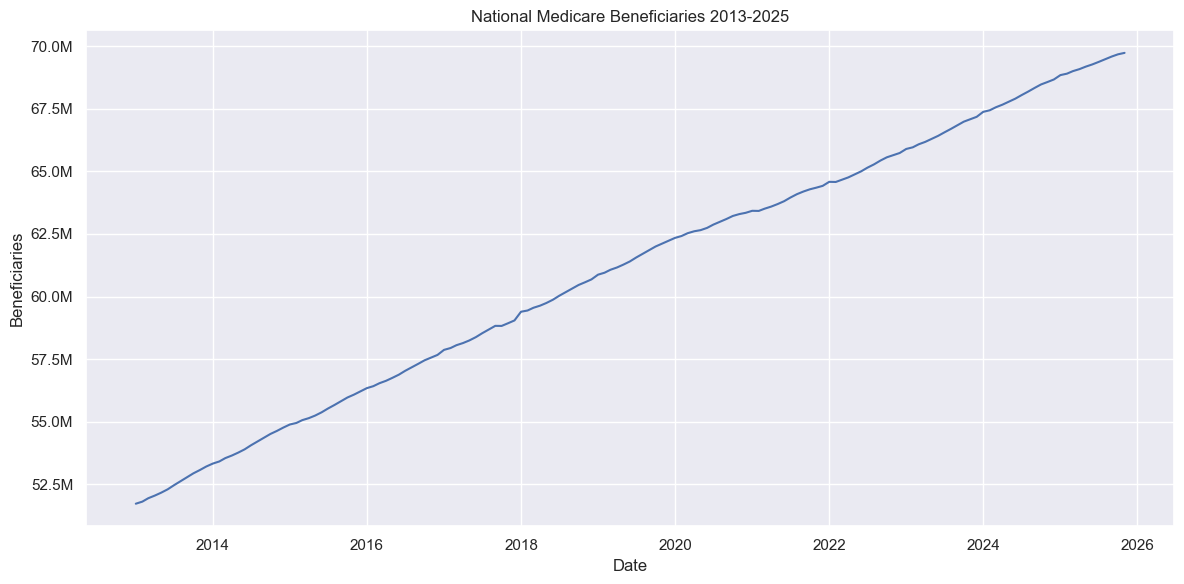

In [19]:
sns.set_theme()

fig, ax = plt.subplots(figsize=(12,6))

ax.plot(
    tot_benes_national_monthly['DATE'],
    tot_benes_national_monthly['TOT_BENES']
)

ax.set_title("National Medicare Beneficiaries 2013-2025")
ax.set_xlabel("Date")
ax.set_ylabel("Beneficiaries")

# Format y-axis in millions
def millions(x, pos):
    return f'{x/1_000_000:.1f}M'

ax.yaxis.set_major_formatter(FuncFormatter(millions))

plt.tight_layout()
plt.show()

## Stacked area chart of total enrollment over time by enrollment type

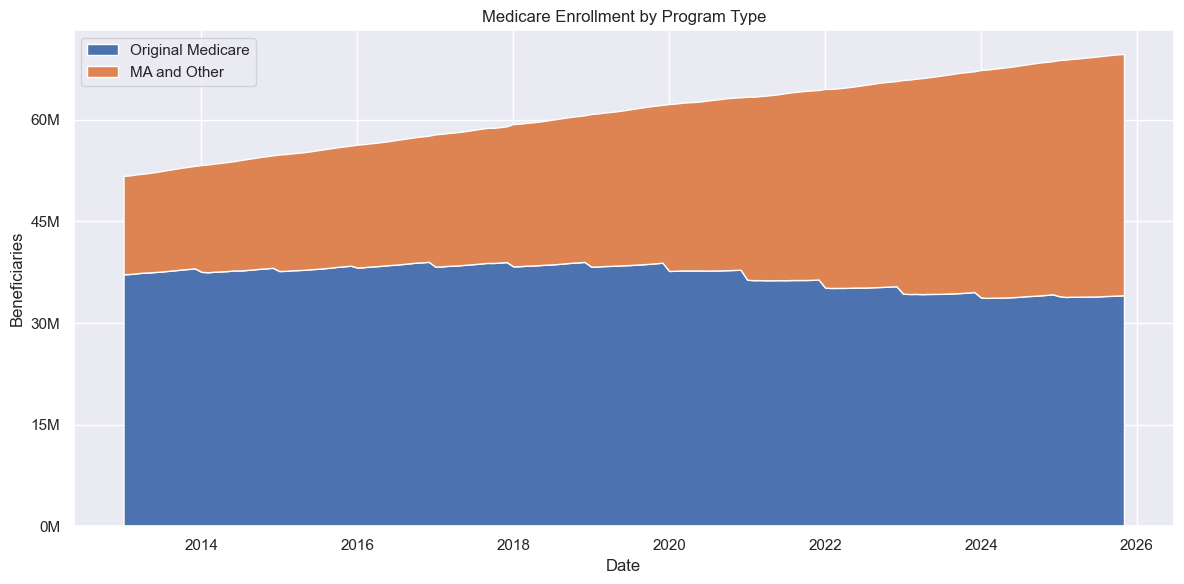

In [20]:
# Sort by date just in case
df_medicare_type = df_national_monthly.sort_values('DATE')

# Create stacked area chart
fig, ax = plt.subplots(figsize=(12,6))

ax.stackplot(
    df_medicare_type['DATE'],
    df_medicare_type['ORGNL_MDCR_BENES'],
    df_medicare_type['MA_AND_OTH_BENES'],
    labels=['Original Medicare', 'MA and Other']
)

# Titles and labels
ax.set_title('Medicare Enrollment by Program Type')
ax.set_xlabel('Date')
ax.set_ylabel('Beneficiaries')

# Y-axis: limit number of ticks and format in millions
ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=6))
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{int(x/1e6)}M'))

# Remove minor ticks
ax.minorticks_off()

# Legend
ax.legend(loc='upper left')

plt.tight_layout()
plt.show()

## Stacked area chart of total enrollment over time by race

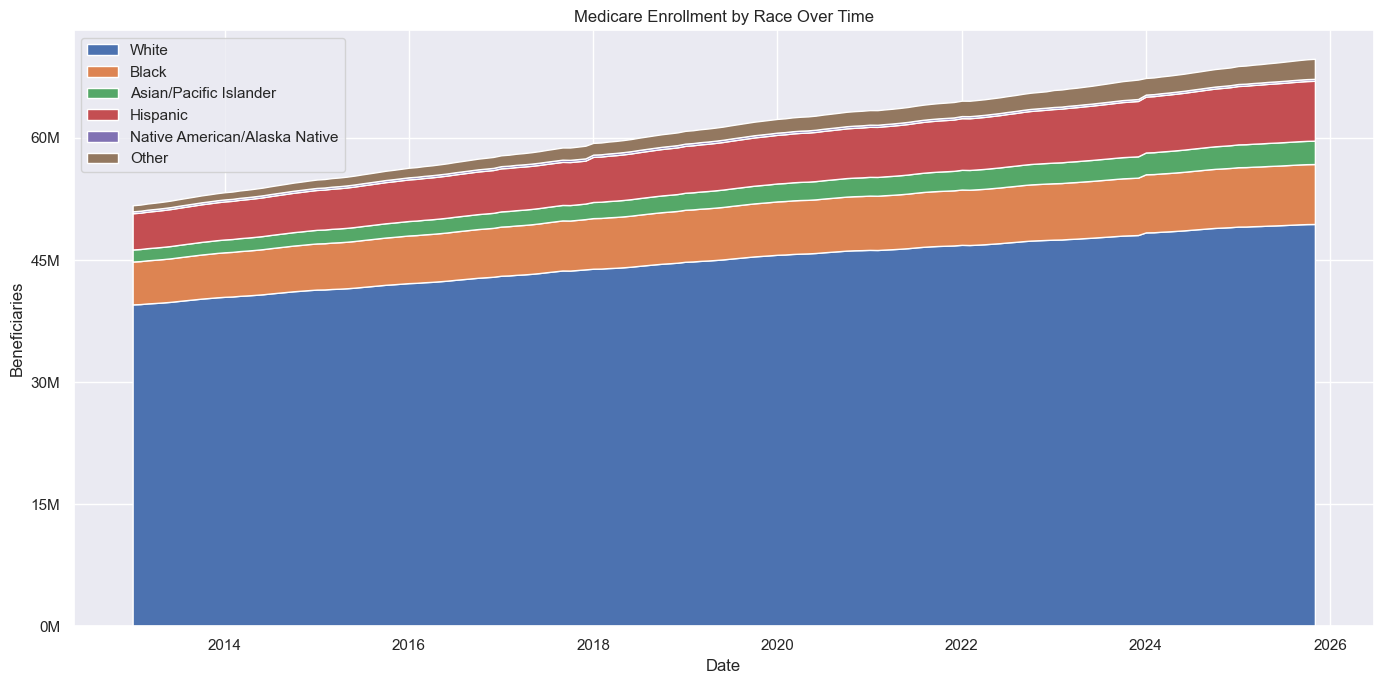

In [21]:
# Filter national level and sort by date
df_race = df_national_monthly.sort_values('DATE')

# Plot stacked area chart
fig, ax = plt.subplots(figsize=(14,7))

ax.stackplot(
    df_race['DATE'],
    [df_race[col] for col in race_cols],
    labels=['White', 'Black', 'Asian/Pacific Islander', 'Hispanic', 'Native American/Alaska Native', 'Other']
)

ax.set_title('Medicare Enrollment by Race Over Time')
ax.set_xlabel('Date')
ax.set_ylabel('Beneficiaries')

# Format y-axis in millions
ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=6))
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{int(x/1e6)}M'))

ax.minorticks_off()
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()